<a href="https://colab.research.google.com/github/yutoshima/news_finance/blob/main/news_finance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install janome
!pip install neologdn
!pip install demoji
!pip install yfinance
!pip install gensim
!pip install textblob
!pip install sklearn
!pip install requests
!pip install bs4
!pip install re
!pip install numpy
!pip install time

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
ERROR: Could not find a version that satisfies the requirement re (from versions: none)
ERROR: No matching distribution found for re
ERROR: Could not find a version that satisfies the requirement time (from versions: none)
ERROR: No matching distribution found for time


In [ ]:
# ライブラリのインポート
import pandas as pd
import yfinance as yf
from janome.tokenizer import Tokenizer
import neologdn
import demoji
from gensim.models import Word2Vec
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from textblob import TextBlob
import requests
from bs4 import BeautifulSoup
import re
import datetime
import numpy as np
import time
from datetime import datetime

In [ ]:
# 定数の定義
TICKER = "^N225"

In [ ]:
stop_words = ['', '以降', '係', 'ちゃ', 'そっち', '市', '簿', '方法', '別', 'ので', '地', 'よう', 'それぞれ', 'みつ', '者', 'ん', '二', '手段', '本当', '場', '系', 'なる', '段', 'ため', 'これ', '俺', '違い', '九', 'う', '億', '内', 'かく', 'どう', '次', 'ひとつ', '情', '手', 'かたち', '列', 'へん', '行', '府', 'みんな', '左', 'はず', '何人', 'てん', '四', '性', 'しよう', 'まま', '右', '時間', 'がら', '年生', '界', 'ぶり', 'か', '0', '店', 'どこ', '円', 'あな', 'ぜんぶ', '化', '都', '力', '匹', '万', 'すね', '火', 'だに', '百', 'みたい', 'よそ', 'あっち', 'は', '書', 'さ', '年', '人', 'さん', 'し', '全部', 'ちゃん', '事', '連', 'より', '冬', '七', '紀', '奴', '様', '等', '輪', '楽', 'ごっちゃ', '六', 'どちら', 'あちら', '先', '千', '下', 'うち', '室', '体', 'どっか', 'ごろ', '線', 'あと', 'これら', '婦', '私', 'やら', 'レ', '作', 'いつ', 'ほか', 'その', 'あなた', '同じ', '国', '法', '部', 'ヵ所', '扱い', '第', '男', '関係', '中', 'え', 'こちら', 'だ', 'すか', 'です', 'ところ', 'ごと', 'だけ', 'いや', '箇月', 'って', '員', '校', '集', '向こう', '子', '通', 'まし', '今回', '夏', 'こっち', 'きた', '結局', '枚', 'ヶ月', 'そちら', 'ぺん', '形', '歳', 'など', 'が', 'わ', 'どれ', 'ばかり', '下記', 'そして', 'あたり', '以下', 'や', 'ヵ月', '以後', 'しか', 'せる', '十', 'まとも', 'さえ', '台', 'では', '彼女', '半ば', '区', '自体', 'とき', '達', '用', '所', '品', '個', 'ち', 'みなさん', '士', 'を', '名', 'もと', '課', '席', 'はるか', '境', '文', '前回', 'なり', 'から', '伸', '一つ', '木', '方', 'の', '毎日', 'ます', 'もん', '観', '確か', '話', 'も', '何', '未満', '様々', '三', '他', 'しかた', '屋', 'くせ', 'すべて', 'て', 'あそこ', '毎', 'わたし', 'おおまか', '我々', '秒', '類', '数', '女', '誰', 'よ', '器', '束', 'ふく', '町', 'そで', '近く', 'がい', 'こと', 'その後', '五', '金', '略', '時', '哀', '家', 'お', 'どこか', '彼', '分', 'いま', 'それ', 'なに', '上記', '感じ', '字', '週', '新た', '首', '外', '日', 'おれ', 'やつ', '上', '頃', 'この', '八', 'た', 'ず', '月', 'そこ', 'かやの', 'とおり', 'おまえ', 'ただ', '目', '兆', '秋', '歴', 'へ', 'ここ', 'あれ', '的', '春', '怒', '高', '回', '度', 'カ月', 'はじめ', 'ほど', 'ない', 'どっち', '土', '以前', 'まさ', 'いろいろ', 'だめ', '論', 'さらい', 'さまざま', 'に', 'カ所', '箇所', '口', '誌', 'れる', '幾つ', '面', 'また', '後', '以上', 'わけ', '喜', '気', '自分', 'だの', 'でし', '村', 'なか', 'なかば', 'いくつ', 'そう', '場合', '間', 'たび', '各', 'ほう', '今', '前', '道', 'する', '点', '時点', 'ずつ', 'ひと', 'な', '名前', '元', '一', 'べつ', 'たくさん', '県', '式', 'なん', '水', 'のに', '多く', 'ませ', 'こそ', '例', '玉', 'もの', '感', 'で', '際', 'ヶ所', '見', 'それなり', 'ね', 'たち', '会']

In [ ]:
# 日程の抽出
dt_now = datetime.now()

In [ ]:
# ファイナンスデータを収集する関数
def collect_finance_data(ticker):
    try:
        data = yf.download(ticker, period='max', interval="1d")
        data.reset_index(inplace=True)
        data['Date'] = pd.to_datetime(data['Date'])
        return data
    except Exception as e:
        print(f"Finance data collection error: {e}")
        return pd.DataFrame()

In [ ]:
def collect_news_data():
    news_df = pd.DataFrame()
    for month in range(1, 13):
        for day in range(1, 32):
            year = datetime.now().year if (month, day) <= (datetime.now().month, datetime.now().day) else datetime.now().year - 1
            url = f"https://www.asahi.com/news/daily/{str(month).zfill(2)}{str(day).zfill(2)}.html"
            try:
                response = requests.get(url)
                soup = BeautifulSoup(response.content, 'html.parser')
                list_items = soup.find('ul', class_='List').find_all('li')
                for item in list_items:
                    title = item.find('a').text.strip().split("(")[0]
                    date_str = f"{year}-{str(month).zfill(2)}-{str(day).zfill(2)}"
                    news_df = pd.concat([news_df, pd.DataFrame({'Date': [date_str], 'Title': [title]})], ignore_index=True)
            except:
                continue
    news_df['Date'] = pd.to_datetime(news_df['Date'])
    return news_df

In [ ]:
# テキストの前処理を行う関数
def preprocess(text):
    # 改行コードの削除
    text = text.replace('\n', '').replace('\r', '')

    # URL削除
    text = re.sub(r'https?://[\w/:%#\$&\?\(\)~\.=\+\-]+', '', text)
    text = re.sub(r'http?://[\w/:%#\$&\?\(\)~\.=\+\-]+', '', text)

    # 絵文字の削除
    text = demoji.replace(text, '')

    # 半角記号削除
    text = re.sub(r'[!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~「」〔〕“”〈〉『』【】＆＊・（）＄＃＠。、？！｀＋￥％]', '', text)

    # 全角記号削除
    text = re.sub("[\uFF01-\uFF0F\uFF1A-\uFF20\uFF3B-\uFF40\uFF5B-\uFF65\u3000-\u303F]", '', text)

    # 全角英数字を半角に変換・長音記号の正規化処理
    text = neologdn.normalize(text)

    # 桁区切り数字を0に変換
    text = re.sub(r'\b\d{1,3}(,\d{3})*\b', '0', text)

    # 数値を全て0に変換
    text = re.sub(r'\d+', '0', text)

    # 大文字を小文字に統一
    text = text.lower()

    return text

In [ ]:
# 単語の抽出を行う関数
def partOfSpeechAnalysis(text):
    # Janomeのトークナイザーを初期化
    tokenizer = Tokenizer()

    # テキストを品詞分解する
    tokens = tokenizer.tokenize(text)

    newText = []
    # 結果を表示
    for token in tokens:
        if token.base_form not in stop_words:
            newText.append(token.base_form)
    return newText

In [ ]:
# Word2Vecモデルのトレーニングを行う関数
def train_word2vec(words):
    model = Word2Vec(words, min_count=1)  # min_countは最低出現回数を指定します
    return model

# 単語のベクトル表現を取得する関数
def get_word_vector(model, word):
    return model.wv[word]

In [ ]:
# 株価の騰落データを取得する関数
def get_updown_finance(finance_data):
    upDownFinance = []
    for i in range(0,len(finance_data)-1):
        Date = finance_data.iloc[i, finance_data.columns.get_loc("Date")]
        upDownVar = finance_data.iloc[i+1, finance_data.columns.get_loc("Open")] - finance_data.iloc[i, finance_data.columns.get_loc("Open")]
        upDown = 1 if upDownVar >= 1 else 0
        upDownFinance.append([Date,upDown])
    upDownFinanceDf = pd.DataFrame( upDownFinance , columns=["Date", "upDown"])
    upDownFinanceDf['Date'] = pd.to_datetime(upDownFinanceDf['Date'])
    return upDownFinanceDf

# ニュースデータと株価データの結合を行う関数
def merge_data(news_data, upDownFinanceDf):
    newsUpDownFinance = pd.merge(news_data, upDownFinanceDf, on="Date", how="outer")
    return newsUpDownFinance

In [ ]:
# ファイナンスデータの収集
finance_data = collect_finance_data(TICKER)

[*********************100%%**********************]  1 of 1 completed


In [ ]:
# ニュースデータの収集
news_data = collect_news_data()

In [ ]:
# テキストの前処理
news_data["processed_text"] = news_data["Title"].apply(preprocess)

In [ ]:
# 単語の抽出
news_data["words"] = news_data["processed_text"].apply(partOfSpeechAnalysis)

In [ ]:
# Word2Vecモデルのトレーニング
model = train_word2vec(news_data["words"])

# 単語のベクトル表現を取得
news_data["word_vector"] = news_data["words"].apply(lambda words: [get_word_vector(model, word) for word in words])

# 株価の騰落データを取得
upDownFinanceDf = get_updown_finance(finance_data)

# ニュースデータと株価データの結合
newsUpDownFinance = merge_data(news_data, upDownFinanceDf)

# Noneを削除
newsUpDownFinance = newsUpDownFinance.dropna()

In [ ]:
# 感情分析
newsUpDownFinance["polarity"] = newsUpDownFinance["Title"].apply(lambda title: TextBlob(title).sentiment.polarity)
newsUpDownFinance["subjectivity"] = newsUpDownFinance["Title"].apply(lambda title: TextBlob(title).sentiment.subjectivity)

# 特徴量エンジニアリング
newsUpDownFinance["mean_vector"] = newsUpDownFinance["word_vector"].apply(lambda x: np.mean(x, axis=0))
newsUpDownFinance["Date"] = pd.to_datetime(newsUpDownFinance["Date"])
newsUpDownFinance = newsUpDownFinance.dropna()

# 特徴量と目的変数の選択
X = newsUpDownFinance[["mean_vector", "polarity", "subjectivity"]].values.tolist()
y = newsUpDownFinance["upDown"].values.tolist()

/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,


In [ ]:
pd.set_option('display.max_rows', 10)
pd.set_option('display.max_columns', 10)
news_data

,Date,Title,processed_text,words,word_vector
0,2024-01-01,【速報中】16都府県警、石川県に広域緊急援助隊を派遣 計数百人,速報中0都府県警石川県に広域緊急援助隊を派遣計数百人,"[速報, 府県警, 石川, 広域, 緊急, 援助, 隊, 派遣, 計数]","[[-0.065201655, 1.8678377, 0.18364082, -0.4728..."
1,2024-01-01,志賀原発の変圧器で油漏れ、消火設備起動も 規制庁「冷却は継続」,志賀原発の変圧器で油漏れ消火設備起動も規制庁冷却は継続,"[志賀, 原発, 変圧, 油, 漏れ, 消火, 設備, 起動, 規制, 庁, 冷却, 継続]","[[0.07376864, 0.27589378, 0.15335989, 0.006303..."
2,2024-01-01,午後11時の「石川県で震度7」は誤報 気象庁、発表を取り消し,午後0時の石川県で震度0は誤報気象庁発表を取り消し,"[午後, 石川, 震度, 誤報, 気象庁, 発表, 取り消し]","[[-0.081235506, 0.45105985, 0.11622859, 0.0201..."
3,2024-01-01,地震でけが人複数、輪島市では火災 建物倒壊や土砂災害の危険高まる,地震でけが人複数輪島市では火災建物倒壊や土砂災害の危険高まる,"[地震, けが人, 複数, 輪島, 火災, 建物, 倒壊, 土砂, 災害, 危険, 高まる]","[[0.4247635, 0.42676058, 0.4452765, -0.6771564..."
4,2024-01-01,【速報中】ウクライナ軍トップ「2024年は容易ではない」,速報中ウクライナ軍トップ0年は容易ではない,"[速報, ウクライナ, 軍, トップ, 容易]","[[-0.065201655, 1.8678377, 0.18364082, -0.4728..."
...,...,...,...,...,...
48567,2023-12-31,日本レコード大賞 大賞はミセス 「地に足つけ曲を作っていきたい」,日本レコード大賞大賞はミセス地に足つけ曲を作っていきたい,"[日本, レコード, 大賞, 大賞, ミセス, 足, つけ, 曲, 作る, いく, たい]","[[0.7106874, 0.64561075, 0.6199754, 0.24240857..."
48568,2023-12-31,多摩川のスーツケースの遺体は46歳男性 殺人・死体遺棄容疑で捜査,多摩川のスーツケースの遺体は0歳男性殺人・死体遺棄容疑で捜査,"[多摩川, スーツケース, 遺体, 男性, 殺人, ・, 死体, 遺棄, 容疑, 捜査]","[[0.024828188, 0.12383677, 0.07012368, 0.00295..."
48569,2023-12-31,お笑い芸人の坂田利夫さん死去 82歳 「アホの坂田」で親しまれ,お笑い芸人の坂田利夫さん死去0歳アホの坂田で親しまれ,"[お笑い, 芸人, 坂田, 利夫, 死去, アホ, 坂田, 親しむ]","[[0.024689436, 0.17571688, 0.10670599, 0.04345..."
48570,2023-12-31,朝日新聞デジタルトップに戻る,朝日新聞デジタルトップに戻る,"[朝日新聞, デジタル, トップ, 戻る]","[[0.24899332, 1.3329312, 0.73419255, 0.7463714..."


In [ ]:
word_updown = newsUpDownFinance.loc[:,["words","upDown"]]
word_updown_exploded = word_updown.explode("words")
word_01 = word_updown_exploded.groupby("words").value_counts().unstack(fill_value=0)

In [ ]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
word_01[word_01[0.0] >=word_01[1.0]*2 ]

upDown,0.0,1.0
words,,
!!,2,0
#,5,2
%…,1,0
%→,4,1
',3,0
...,1,0
aaa,2,0
abema,1,0
acl,2,1


Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 38651 (\N{CJK UNIFIED IDEOGRAPH-96FB}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 30977 (\N{CJK UNIFIED IDEOGRAPH-7901}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27598 (\N{CJK UNIFIED IDEOGRAPH-6BCE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 24195 (\N{CJK UNIFIED IDEOGRAPH-5E83}) missing from current fo

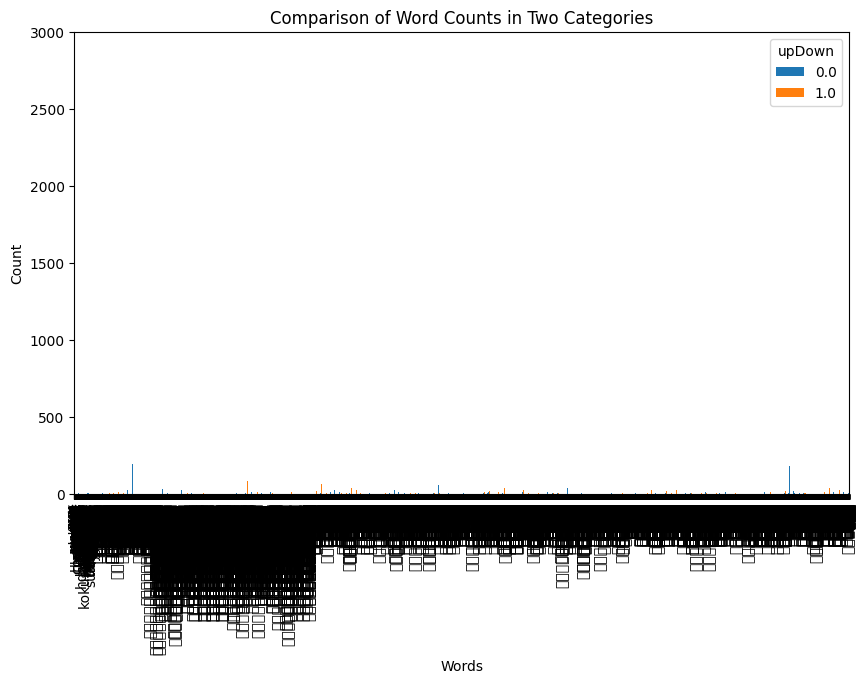

In [ ]:
from matplotlib import pyplot as plt

word_01.plot(kind='bar', figsize=(10, 6))
plt.title('Comparison of Word Counts in Two Categories')
plt.xlabel('Words')
plt.ylabel('Count')
plt.show()

In [ ]:
news_data

In [ ]:
"""
# データ分割
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# モデル学習
model = LogisticRegression()
model.fit(X_train, y_train)

# モデル評価
score = model.score(X_test, y_test)
print(f"テストデータの精度: {score}")

# 交差検証
scores = cross_val_score(model, X, y, cv=5)
print(f"交差検証による平均精度: {scores.mean()}")

# 新しいニュース記事の予測
new_text = "【速報中】16都府県警、石川県に広域緊急援助隊を派遣　計数百人"
new_processed_text = preprocess(new_text)
new_words = partOfSpeechAnalysis(new_processed_text)
new_mean_vector = np.mean([get_word_vector(model, word) for word in new_words], axis=0)
new_blob = TextBlob(new_processed_text)
new_polarity = new_blob.sentiment.polarity
new_subjectivity = new_blob.sentiment.subjectivity
new_data = pd.DataFrame({"mean_vector": [new_mean_vector], "polarity": [new_polarity], "subjectivity": [new_subjectivity]})

# 予測
y_pred = model.predict(new_data)

# 結果の出力
if y_pred == 1:
    print("株価は上昇する可能性があります")
else:
    print("株価は下落する可能性があります")
"""